In [47]:
import importlib
import src.data_loader as dl
import src.VaR as vr
import src.stats as st
import src.CVaR as cv
import src.metrics as mt
from src.plots import plot_var_comparison, plot_cumulative_return, plot_heatmap, plot_drawdown

In [30]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
tickers = ["AAPL", "MSFT", "JPM", "GS", "XOM", "JNJ", "TSLA", "SPY", "GLD", "TLT"]
weights = 10 * [0.1]

In [3]:
prices = dl.get_price_data(tickers)

[*********************100%***********************]  10 of 10 completed


In [4]:
# no missing values, data is clean
prices.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1255 entries, 2021-05-11 to 2026-05-08
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    1255 non-null   float64
 1   GLD     1255 non-null   float64
 2   GS      1255 non-null   float64
 3   JNJ     1255 non-null   float64
 4   JPM     1255 non-null   float64
 5   MSFT    1255 non-null   float64
 6   SPY     1255 non-null   float64
 7   TLT     1255 non-null   float64
 8   TSLA    1255 non-null   float64
 9   XOM     1255 non-null   float64
dtypes: float64(10)
memory usage: 107.9 KB


In [5]:
log_returns = dl.compute_log_returns(prices)
portfolio_returns = dl.compute_portfolio_returns(log_returns, weights)

In [6]:
print(portfolio_returns)

Date
2021-05-12   -0.016338
2021-05-13    0.005650
2021-05-14    0.017402
2021-05-17   -0.000716
2021-05-18   -0.008271
                ...   
2026-05-04   -0.008610
2026-05-05    0.007133
2026-05-06    0.008552
2026-05-07   -0.002195
2026-05-08    0.004273
Length: 1254, dtype: float64


In [7]:
hist_var = vr.calc_hist_var(portfolio_returns)
print(hist_var)

0.014929290537913444


In [8]:
par_var = vr.calc_parametric_var(portfolio_returns)
print(par_var)

0.015451279086751544


In [9]:
mc_var = vr.calc_mc_var(log_returns, weights)
print(mc_var)

0.015453468016071007


In [10]:
skew = st.calculate_skew_kurt(portfolio_returns)
print(skew['skewness'])
print(skew['kurtosis'])

0.12958793054551687
6.185507483145356


In [11]:
# kurtosis > 0 means there are 'fat tails', the distribution is not normal

Figure(1200x700)


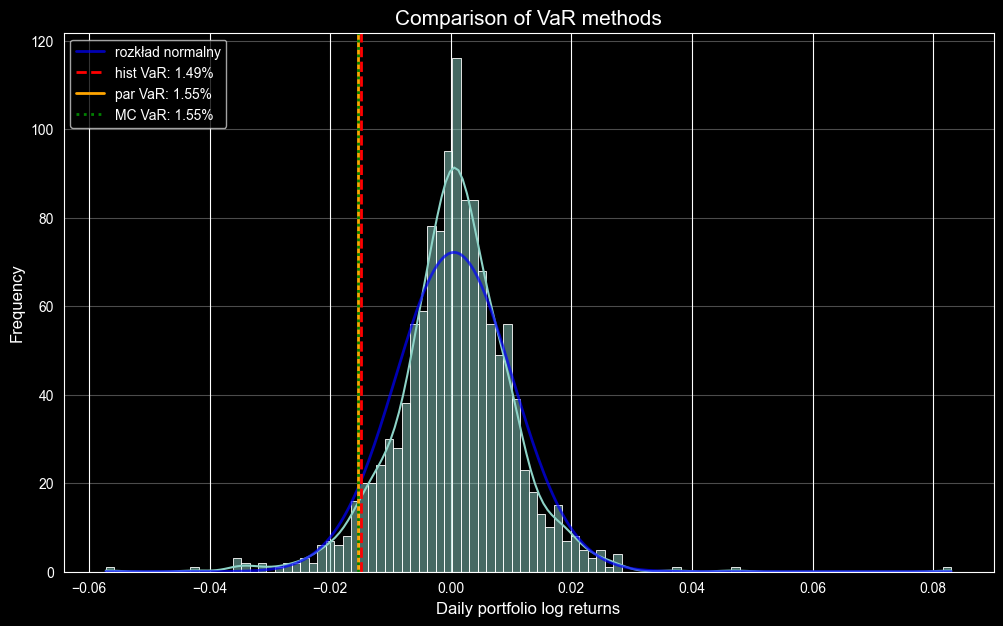

In [31]:
fig = plot_var_comparison(portfolio_returns, hist_var, par_var, mc_var)
print(fig)

In [13]:
hist_cvar = cv.calc_hist_cvar(portfolio_returns)
print(hist_cvar)

0.021782814983261106


In [14]:
par_cvar = cv.calc_parametric_cvar(portfolio_returns)
print(par_cvar)

0.019513437267917193


In [ ]:
%%sql


In [15]:
"""
VaR historyczny i parametryczny są praktycznie identyczne, ale CVaR się różnią.
Oznacza to, że dane mają grube ogony i rozkład nie jest normalny, a zbliżony bardziej do rozkładu
t-Studenta. Należy to zweryfikować metodą .fit() z użyciem scipy.stats
"""

'\nVaR historyczny i parametryczny są praktycznie identyczne, ale CVaR się różnią.\nOznacza to, że dane mają grube ogony i rozkład nie jest normalny, a zbliżony bardziej do rozkładu\nt-Studenta. Należy to zweryfikować metodą .fit() z użyciem scipy.stats\n'

In [16]:
jarque_bera = st.test_normality(portfolio_returns)
print(jarque_bera)

{'jb_stat': 1983.6434575686976, 'jb_p': 0.0, 'is normal': False}


In [17]:
t_student = st.fit_t_distribution(portfolio_returns)
print(t_student)

{'df': 4.417517521174496, 'loc': 0.000705768853935073, 'scale': 0.007214037018283421}


In [18]:
"""
Wnioski:
test jarque-bera pokazał, że rozkład nie jest normalny, występuje silna kurtoza
parametr v (stopnie swobody) przy dopasowaniu rozkładu t-studenta potwierdza, że dane mają rozkład t-studenta i występują grube ogony
oznacza to, że policzony VaR historyczny i monte carlo są niedoszacowane, pominięte zostały wartości ekstremalne
potwierdza to również porównanie CVaR historycznego i parametrycznego, gdzie parametryczny jest wyraźnie mniejszy
należałoby więc zmienić dopasowanie rozkładu z normalnego na t-studenta.
"""

'\nWnioski:\ntest jarque-bera pokazał, że rozkład nie jest normalny, występuje silna kurtoza\nparametr v (stopnie swobody) przy dopasowaniu rozkładu t-studenta potwierdza, że dane mają rozkład t-studenta i występują grube ogony\noznacza to, że policzony VaR historyczny i monte carlo są niedoszacowane, pominięte zostały wartości ekstremalne\npotwierdza to również porównanie CVaR historycznego i parametrycznego, gdzie parametryczny jest wyraźnie mniejszy\nnależałoby więc zmienić dopasowanie rozkładu z normalnego na t-studenta.\n'

In [36]:
sharpe_ratio = mt.sharpe(portfolio_returns)
print(sharpe_ratio)

0.5560481796214394


In [35]:
sortino_ratio = mt.sortino(portfolio_returns)
print(sortino_ratio)

0.7984288581997835


In [37]:
mdd = mt.mdd(portfolio_returns)
print(mdd)

-0.2043783124273905


In [38]:
calmar = mt.calmar(portfolio_returns)
print(calmar)

0.41986025724395304


Figure(1200x700)


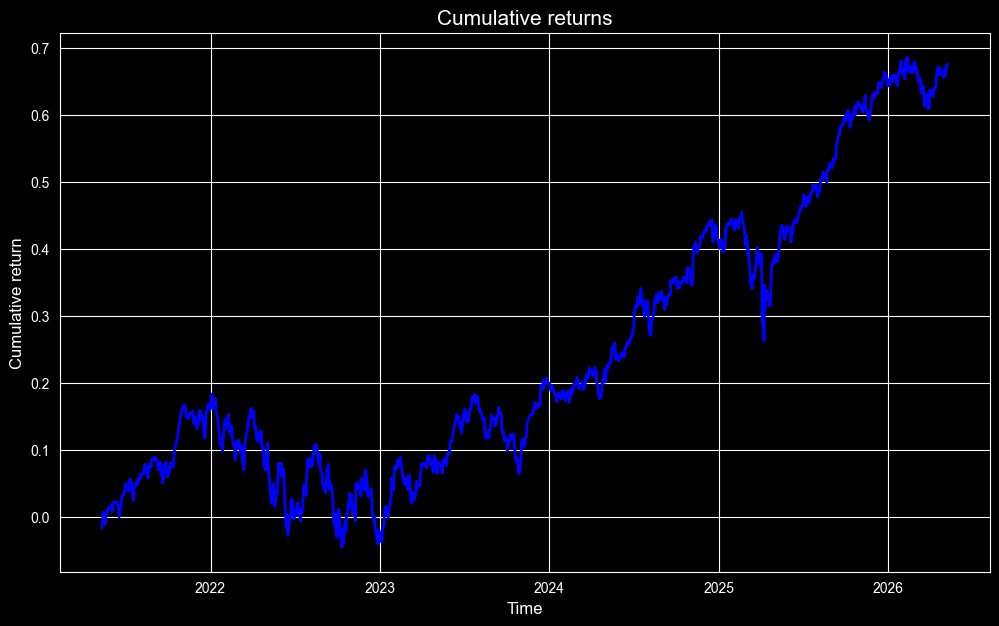

In [41]:
fig = plot_cumulative_return(portfolio_returns)
print(fig)

Figure(1200x700)


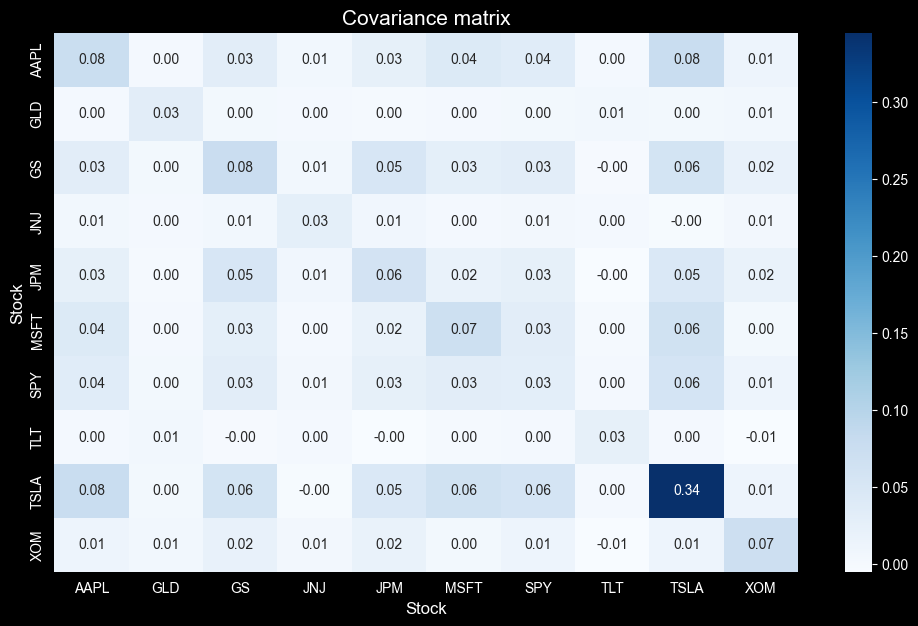

In [46]:
annual_cov = log_returns.cov() * 252
fig = plot_heatmap(cov_matrix=annual_cov)
print(fig)

Figure(1200x600)


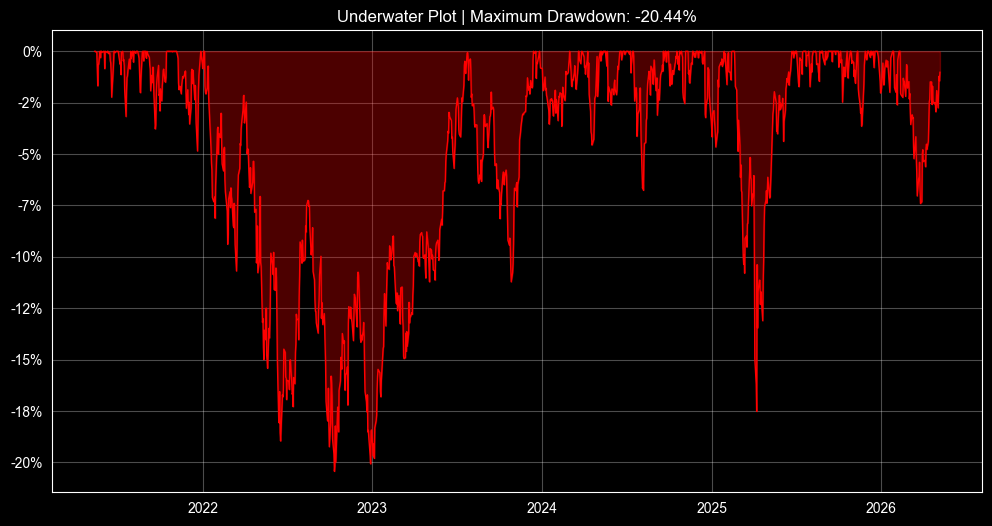

In [48]:
fig = plot_drawdown(portfolio_returns)
print(fig)